In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2025-05-16 14:54:48.791258: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Problem Statement
In this we will use neural network to recognize the handwritten digits 0-9. This is a multiclass classification task where one of n choices is selected. Automated handwritten digit recognition is widely used today - from recognizing zip codes (postal codes) on mail envelopes to recognizing amounts written on bank checks.

In [2]:
# Load the MNIST dataset from keras
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the pixel values to [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# check shapes
print("Train: ", x_train.shape, y_train.shape)
print("Test: ", x_test.shape, y_test.shape)

Train:  (60000, 28, 28) (60000,)
Test:  (10000, 28, 28) (10000,)


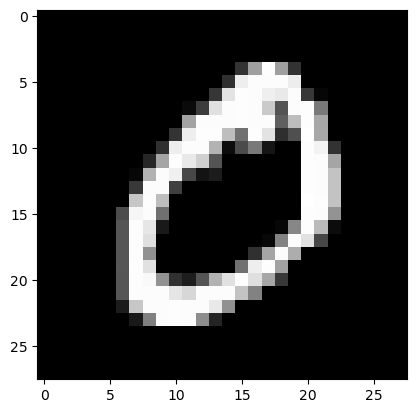

In [3]:
# Let's visualize how the data looks like with a single image
plt.imshow(x_train[1], cmap='gray')

# About the dataset
The dataset contains 60000 training examples of handwritten digits, with it's acutal labels along with 10000 testing examples with it actual labels for testing.
- Each example is a `28-pixel * 28-pixel` grayscale image of the digit.
    - Each pixel is represented by a floating-point number indicating the grayscale intensity at that location.
    - The 28 by 28 grid of pixels is "unrolled" into a `784-dimensional vector`.
    - Each training examples becomes a single row in our data matrix.
    - This gives us a 60000 x 784 matrix when we flatten.
    - Also we normalize our data to [0, 1]
- The second part of the training set is 60000 x 1 dimensional vector y_train that contains labels for the training set
    - `y_train = 0` if the image is of the digit `0`, `y_train = 4` if the image is of the digit `4` and so on.


#### Why normalize our data to [0, 1]
    1. Improves model performance and convergance speed:
        * Neural networks train faster and more reliably when input features are on a similar scale.
        * This helps gradient descent work more effectively.
    2. Avoids large gradients or exploding weights:
        * Large input values can cause unstable training or exploding gradients in deeper layers.
    3. Consistency with activation functions: 
        * Many activations (like sigmord, relu or tanh) behave better with small input ranges.
        
In summary, this step makes learning more efficient and stable for the neural network.

# View the variables
Let's get more familiar with our dataset
    - A good place to start is to print out each variable and see what it contains.

In [4]:
# Flatten images from (28, 28) to (784, )
x_train_flat = x_train.reshape(-1, 784).astype("float32")
print('The first element of x_train_flat is: ', x_train_flat[0])

The first element of x_train_flat is:  [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.   

### check the dimensions of our variables and what y_train contains
- Another way to get familiar with our data is to view it's dimensions and what y label contains

In [5]:
print('Shape of each row: ',x_train_flat[0].shape)
print('Shape of x_train_flat is: ', x_train_flat.shape)

print('The first element of y_train is: ', y_train[0])
print('The last element of y_train is: ', y_train[-1])

Shape of each row:  (784,)
Shape of x_train_flat is:  (60000, 784)
The first element of y_train is:  5
The last element of y_train is:  8


#### Visualizing the Data
We will visualize a subset of the training set
    - In the cell below, the code randomly selects 64 rows from x_train and displays the image.
    - The label for each of the image is displayed above the image

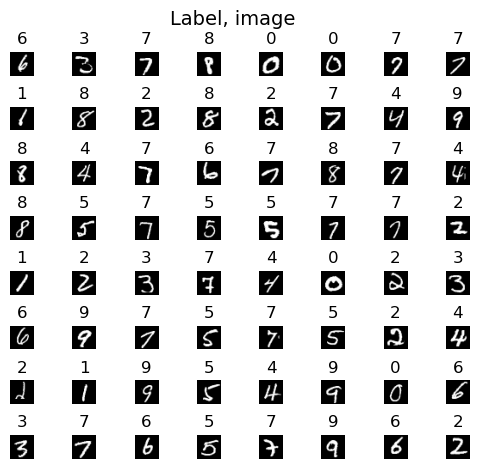

In [6]:
# import warnings
# warnings.simplefilter(action='ignore', category=FutureWarning)

m, n = x_train_flat.shape

fig, axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13, rect=[0, 0.03, 1, 0.91]) #[left, bottom, right, top]

#fig.tight_layout(pad=0.5)
# widgvis(fig)
for i, ax in enumerate(axes.flat):
    # select random indices
    random_index = np.random.randint(m)
    
    # display the image
    ax.imshow(x_train[random_index], cmap='gray')
    
    # display the label above the image
    ax.set_title(y_train[random_index])
    ax.set_axis_off()
    fig.suptitle("Label, image", fontsize=14)

### Model representation
The neural network we will be using is shown in the figure below.
- This has two dense layers with ReLU activations followed by an output layer with linear activation followed by softmax.
    - Recall that our inputs are pixel values of digit images that we normalized to [0,1] before feeding to our Neural Network.
    
    
#### ReLU Activation
Rectified Linear Unit (ReLU) 
$$ a = max(0,z) \quad\quad\text {# ReLU function} $$

#### Softmax Function
A multiclass neural network generates N outputs. One output is selected as the predicted answer. In the output layer, a vector $\mathbf{z}$ is generated by a linear function which is fed into a softmax function. 
The softmax function converts $\mathbf{z}$ into a probability distribution as described below. After applying softmax, each output will be between 0 and 1 and the output sum to 1. They can be interpreted as probabilities. The larger inputs to the softmax will correspond to larger output probabilities.
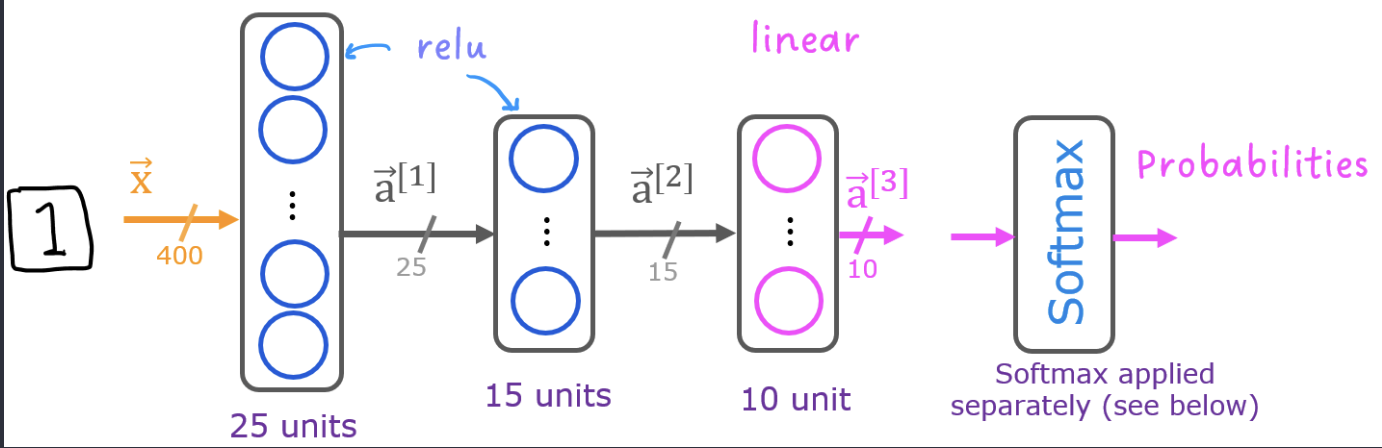
 

#### Softmax placement
- Numerical stability is improved if the softmax is grouped with the loss function rather than the output layer during training. This has implications when *building* the model and *using* the model.

Building:
* The final Dense layer should use a 'linear' activation. This is effectively no activation.
* The `model.compile` statement will indicate this by including `from_logits=True`.
        `loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)`
* This does not impact the form of the target. In the case of SparseCategoricalCrossentropy, the target is the expected digit, 0-9.

Using the model:
* The outputs are not probabilities. If output probabilities are desired, apply a softmax function.

In [7]:
#Build and Train a simple neural network
tf.random.set_seed(1234) # for consistent results
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape = (28, 28)),   # Convert image to 1D
    tf.keras.layers.Dense(25, activation = 'relu'),
    tf.keras.layers.Dense(15, activation = 'relu'),
    tf.keras.layers.Dropout(0.2),                    # to prevent overfitting
    tf.keras.layers.Dense(10, activation = 'linear')
])

2025-05-16 15:11:57.314386: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 25)                19625     
                                                                 
 dense_1 (Dense)             (None, 15)                390       
                                                                 
 dropout (Dropout)           (None, 15)                0         
                                                                 
 dense_2 (Dense)             (None, 10)                160       
                                                                 
Total params: 20,175
Trainable params: 20,175
Non-trainable params: 0
_________________________________________________________________


- The parameter counts shown in the summary corresponds to the number of elements in the weight and bias arrays as shown below

- Recall that the dimensions of these parameters is determined as follows:
        - If network has $s_{in}$ units in a layer and $s_{out}$ units in the next layer, then 
            - $W$ will be of dimension $s_{in} \times s_{out}$.
            - $b$ will be a vector with $s_{out}$ elements
  
    - Therefore, the shapes of `W`, and `b`,  are 
        - Dense layer1: The shape of `W1` is (784, 25) and the shape of `b1` is (25,)
        - Dense layer2: The shape of `W2` is (25, 15) and the shape of `b2` is: (15,)
        - Dense layer3: The shape of `W3` is (15, 10) and the shape of `b3` is: (10,)
>**Note:** The bias vector `b` could be represented as a 1-D (n,) or 2-D (n,1) array. Tensorflow utilizes a 1-D representation and this lab will maintain that convention:

In [10]:
[layer1, layer2, layer3, layer4, layer5] = model.layers

In [11]:
## Examine Weights shapes
# layer1 is just used to flatten the pixels
W2, b2 = layer2.get_weights()
W3, b3 = layer3.get_weights()
# layer4 is used to handle overfitting using dropout
W5, b5 = layer5.get_weights()

# print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")
# print(f"W4 shape = {W4.shape}, b4 shape = {b4.shape}")
print(f"W5 shape = {W5.shape}, b5 shape = {b5.shape}")

W2 shape = (784, 25), b2 shape = (25,)
W3 shape = (25, 15), b3 shape = (15,)
W5 shape = (15, 10), b5 shape = (10,)


The following code:
* defines a loss function, `SparseCategoricalCrossentropy` and indicates the softmax should be included with the loss calculation by adding `from_logits=True`
* defines an optimizer. A popular choice is Adaptive Moment (Adam)

In [12]:
# compile the model
model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
    metrics = ['accuracy']
)

# Train the model
history = model.fit(
    x_train, 
    y_train,
    epochs=40
)

Epoch 1/40
1875/1875 [==============================] - 2s 987us/step - loss: 0.6224 - accuracy: 0.8065
Epoch 2/40
1875/1875 [==============================] - 2s 980us/step - loss: 0.3530 - accuracy: 0.8962
Epoch 3/40
1875/1875 [==============================] - 2s 987us/step - loss: 0.3047 - accuracy: 0.9107
Epoch 4/40
1875/1875 [==============================] - 2s 980us/step - loss: 0.2713 - accuracy: 0.9216
Epoch 5/40
1875/1875 [==============================] - 2s 977us/step - loss: 0.2465 - accuracy: 0.9279
Epoch 6/40
1875/1875 [==============================] - 2s 980us/step - loss: 0.2255 - accuracy: 0.9344
Epoch 7/40
1875/1875 [==============================] - 2s 972us/step - loss: 0.2157 - accuracy: 0.9381
Epoch 8/40
1875/1875 [==============================] - 2s 979us/step - loss: 0.2041 - accuracy: 0.9405
Epoch 9/40
1875/1875 [==============================] - 2s 978us/step - loss: 0.1949 - accuracy: 0.9429
Epoch 10/40
1875/1875 [==============================] - 2s 978u

#### Epochs and batches
In the `compile` statement above, the number of `epochs` was set to 40. This specifies that the entire data set should be applied during training 40 times. During training, you see output describing the progress of training that looks like this:

```
Epoch 1/40
1875/1875 [==============================] - 2s 924us/step - loss: 0.6285
```

The first line `Epoch 1/40`, describes which epoch the model is currently running. For efficiency, the training data set is broken into 'batches'. The default size of a batch in Tensorflow is 32. There are 60000 examples in our dataset or roughly 1875 batches. The notation of the 2nd line `1875/1875 [====` is describing which batch has been executed.


#### Loss (cost)
Ideally, the cost will decrease as the number of iterations of the algorithm increases. Tensorflow refers to the cost as `loss`. Above, you saw the loss displayed each epoch as `mode.fit` was executing the [.fit](https://www.tensorflow.org/api_docs/python/tf/keras/Model) method returns a variety of metrics including the loss. This is captured in the `history` variable above. This can be used to examine the loss in a plot as shown below.

In [13]:
def widgvis(fig):
    fig.canvas.toolbar_visible = False
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False

def plot_loss_tf(history):
    fig,ax = plt.subplots(1,1, figsize = (4,3))
    widgvis(fig)
    ax.plot(history.history['loss'], label='loss')
    ax.set_ylim([0, 2])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('loss (cost)')
    ax.legend()
    ax.grid(True)
    plt.show()

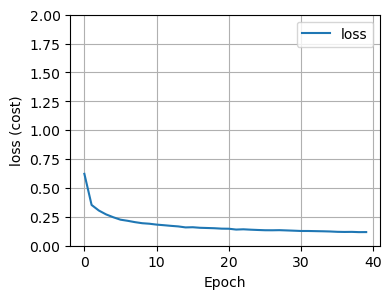

In [14]:
plot_loss_tf(history)

#### Evaluate the Model
Evaluate the model on the test data x_test against labels y_test using the metrics accuracy.
Here:
* `loss` is used for training (gradient updates)
* `Accuracy` is for evaluation of our model (model performance)

In [15]:
# Evaluate the Model
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")


313/313 [==============================] - 0s 740us/step - loss: 0.1966 - accuracy: 0.9580
Test accuracy: 0.9580


#### Prediction
To make prediction, use Keras predict. 

In [16]:
# make the predictions
predictions = model.predict(x_test)

# print the prediction for the first test image
print(predictions[0])
print("Predicted label: ", np.argmax(predictions[0]))
print("Actual Label: ", y_test[0])

313/313 [==============================] - 0s 622us/step
[-38.72206    -6.3532214   3.8646777   5.1104393 -15.215488  -20.45889
 -41.4721     15.434257  -11.217984  -10.327422 ]
Predicted label:  7
Actual Label:  7


The largest output is prediction 7 in the above example, If the problem only requires a selection, this is sufficient. Use Numpy [argmax](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html) to select it. If the problem requires a probability, a softmax is required.

In [17]:
predictions_p = tf.nn.softmax(predictions)

print(f"predicting a Seven. Probability vector: \n{predictions_p[0]}")
print(f"Total of predictions: {np.sum(predictions_p[0]):0.3f}")

predicting a Seven. Probability vector: 
[3.0212824e-24 3.4498515e-10 9.4488150e-06 3.2840126e-05 4.8861424e-14
 2.5809893e-16 1.9313675e-25 9.9995780e-01 2.6610962e-12 6.4837575e-12]
Total of predictions: 1.000


Text(0.5, 1.0, 'Predicted: 7, Actual: 7')

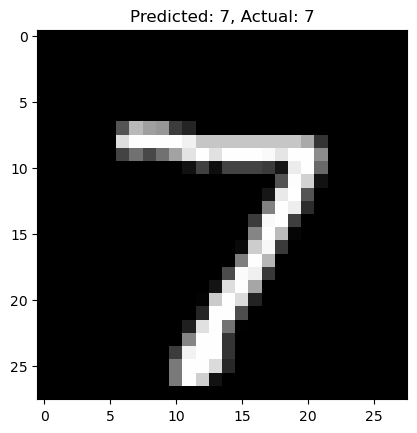

In [18]:
# Visualize an Image and Prediction
plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted: {np.argmax(predictions[0])}, Actual: {y_test[0]}")

Let's compare the predictions vs the labels for a random sample of 64 digits in x_test.

1/1 [==============================] - 0s 18ms/step


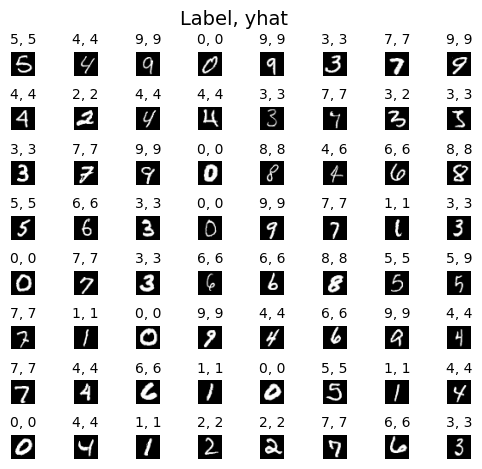

In [19]:
import warnings
warnings.simplefilter(action = 'ignore', category = FutureWarning)

m, n, o = x_test.shape

fig, axes = plt.subplots(8, 8, figsize = (5,5))
fig.tight_layout(pad = 0.13, rect = [0, 0.03, 1, 0.91]) #[left, bottom, right, top]
widgvis(fig)

for i, ax in enumerate(axes.flat):
    # select random indices
    random_index = np.random.randint(m)
    
    # Display the image
    ax.imshow(x_test[random_index], cmap='gray')
    
    # Predict using the Neural Network
    prediction = model.predict(x_test[random_index])
    prediction_p = tf.nn.softmax(prediction)
    yhat = np.argmax(prediction_p)
    
    # Display the label above the image
    ax.set_title(f"{y_test[random_index]}, {yhat}", fontsize = 10)
    ax.set_axis_off()
fig.suptitle("Label, yhat", fontsize=14)
plt.show()

Let's look at some of the errors.
>Note: increasing the number of training epochs can eliminate the errors on this data set.

In [30]:
def display_errors(model,X,y):
    f = model.predict(X)
    yhat = np.argmax(f, axis=1)
    doo = yhat != y
    idxs = np.where(yhat != y)[0]
    if len(idxs) == 0:
        print("no errors found")
    else:
        cnt = min(8, len(idxs))
        fig, ax = plt.subplots(1,cnt, figsize=(5,1.2))
        fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.80]) #[left, bottom, right, top]
        widgvis(fig)

        for i in range(cnt):
            j = idxs[i]

            # Display the image
            ax[i].imshow(X[j], cmap='gray')

            # Predict using the Neural Network
            prediction = model.predict(X[j])
            prediction_p = tf.nn.softmax(prediction)
            yhat = np.argmax(prediction_p)

            # Display the label above the image
            ax[i].set_title(f"{y[j]},{yhat}",fontsize=10)
            ax[i].set_axis_off()
            fig.suptitle("Label, yhat", fontsize=12)
    return(len(idxs))

1/1 [==============================] - 0s 18ms/step
420 errors out of 10000 images


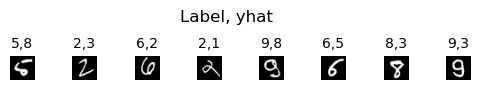

In [31]:
print(f"{display_errors(model, x_test, y_test)} errors out of {len(x_test)} images")